# 4. Runde mit nur noch 5 Modellen
Die bisherigen Optimierungen zeigen: Ein schrittweises Vorgehen war sinnvoll und hat die Modelle nach und nach verbessert. Wichtig bleibt: Nicht einfach nur den Recall maximieren, sondern die wirtschaftliche Bewertung anhand der Zielfunktion im Blick behalten.
Für die letzte Finetuning-Runde werden jetzt die fünf aktuell besten Modelle nochmals feiner optimiert:

- CatBoostClassifier
- GradientBoostingClassifier
- LGBMClassifier
- RandomForestClassifier

- XGBClassifier **--> (macht David und erfolgt daher nicht in diesem Notebook)**


## Hyperparameter-Optimierung & Threshold-Optimierung mit 50 Iterationen

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# neue Modelle (nach pip install)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

In [2]:
# Preprocessor laden
from pipeline.data_pipeline import preprocessor, X, y

## 1. Datenaufteilung

In [3]:

# damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all():
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)


In [4]:
X

,id,store_id,cash_desk,transaction_start,transaction_end,total_amount,n_lines,payment_medium,customer_feedback,opening_date,location,state,urbanization,sco_introduction,transaction_lines_details
2,b642f9b6-43b5-413d-ad08-b4bf4b664b52,b0973ffa-ce15-41e0-9de7-1390598e24f2,2,2022-02-02 08:07:12.000000,2022-02-02 08:11:29.434607,363.87,37,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
5,fc8400da-2ac2-4984-bb8f-a6ea29df955a,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 08:21:12.000000,2022-02-02 08:21:48.404849,75.58,3,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
9,3d7dbe6e-2a67-4a4d-8011-394b44774c53,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 08:48:09.000000,2022-02-02 08:51:20.530141,218.51,23,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
17,d54e5513-bdbe-4129-bafc-dc4a15747260,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 09:11:15.000000,2022-02-02 09:14:02.177041,323.95,27,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
32,6e1a71c4-b210-427e-8882-5385f9b9253e,b0973ffa-ce15-41e0-9de7-1390598e24f2,3,2022-02-02 10:04:06.000000,2022-02-02 10:04:27.311571,58.87,4,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558167,93e0f4b3-810a-46c7-837e-7b84b2a4c673,ed996b17-17d6-47e8-9262-d1d02b52cdb4,0,2023-12-30 21:12:15.000000,2023-12-30 21:13:17.665744,47.28,8,CREDIT_CARD,NaN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558170,81d32eb7-7b5d-48e5-9c25-18a0148ba907,ed996b17-17d6-47e8-9262-d1d02b52cdb4,2,2023-12-30 21:13:18.000000,2023-12-30 21:16:37.092689,264.25,22,CREDIT_CARD,10.0,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558173,14ce6f9e-64a9-4c93-b834-cde34d80704d,ed996b17-17d6-47e8-9262-d1d02b52cdb4,1,2023-12-30 21:14:42.000000,2023-12-30 21:19:28.465321,297.95,38,CREDIT_CARD,NaN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558175,c63b715f-4b23-485a-92e9-7bca82775d4c,ed996b17-17d6-47e8-9262-d1d02b52cdb4,2,2023-12-30 21:16:41.074339,2023-12-30 21:19:32.503266,398.57,27,CREDIT_CARD,NaN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."


## 2. Zielfunktion definieren

In [5]:
def custom_objective_score(y_true, y_pred, damage_series):
    """
    Custom Zielfunktion:
    Score = -Summe Schaden der FN + (5 * TP) - (10 * FP)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    
    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()
    
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## 3. Evaluationsfunktion definieren

In [6]:
def evaluate_model_with_curves(model, model_name, preprocessor, X_train, X_test, y_train, y_test, damage_test, threshold):
    logging.info(f"🔍 Starte Evaluation für Modell: {model_name}")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    if y_train.isnull().any():
        logging.warning(f"y_train enthält NaN-Werte: {y_train.isnull().sum()} fehlende Werte!")
        return

    try:
        pipeline.fit(X_train, y_train)
    except Exception as e:
        logging.exception(f"Fehler beim Training: {e}")
        return

    has_proba = hasattr(model, "predict_proba")
    if has_proba:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)
    else:
        logging.warning("⚠️ Modell unterstützt kein predict_proba.")
        y_scores = None
        y_pred = pipeline.predict(X_test)

    # Klassifikationsbericht
    print("\n📋 Klassifikationsbericht:")
    print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))

    # Konfusionsmatrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n🔲 Konfusionsmatrix:")
    print(cm)
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "FRAUD"]).plot(cmap="Blues")
    plt.title(f"Konfusionsmatrix – {model_name} (Threshold: {threshold:.2f})")
    plt.show()

    # ROC & PR-Kurven
    if has_proba and y_scores is not None:
        auc = roc_auc_score(y_test, y_scores)
        logging.info(f"📈 ROC-AUC: {auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_scores).plot()
        plt.plot([0, 1], [0, 1], 'k--', label='Zufall')
        plt.legend()
        plt.title(f"ROC-Kurve – {model_name}")
        plt.show()

        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        PrecisionRecallDisplay(precision=precision, recall=recall).plot()
        plt.title(f"Precision-Recall-Kurve – {model_name}")
        plt.show()

    if len(y_test) != len(damage_test):
        logging.error("Länge von y_test und damage_test stimmen nicht überein!")
        return

    custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
    print(f"\n🎯 Wert der Zielfunktion: {custom_score:.2f}")

    return custom_score  # Optionaler Rückgabewert

## 4. Randomized Search mit Custom Scoring

In [7]:
def randomized_search_with_custom_score(model_class, param_grid, preprocessor, 
                                        X, y, damage_series, 
                                        model_fixed_params=None, 
                                        n_iter=10, cv_splits=5, random_state=42):
    """
    Randomisierte Hyperparameter-Suche mit Custom Objective Function und optionalen festen Modellparametern.
    """
    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        logging.info(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', model_class(**full_params))
            ])

            try:
                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_valid)
                score = custom_objective_score(
                    y_valid.reset_index(drop=True),
                    y_pred,
                    damage_valid.reset_index(drop=True)
                )
                fold_scores.append(score)
                logging.info(f"  Fold {fold} Score: {score:.2f}")
            except Exception as e:
                logging.error(f"❌ Fehler in Fold {fold}: {e}")
                continue

        if not fold_scores:
            logging.warning(f"⚠️ Keine gültigen Folds in Iteration {iteration+1}.")
            continue

        mean_score = np.mean(fold_scores)
        logging.info(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    logging.info("\n✅ Beste Parameter gefunden!")
    logging.info(f"✅ Parameter: {best_params}")
    logging.info(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score

## 5. Hyperparameter-Setup mit allen Modellen
Die bisherigen optimalen Parameter liefern schon eine klare Tendenz. Komplett breiter Zufalls-Suchraum wäre jetzt nur noch Zeitverschwendung. Jetzt wollen wir daher fokussierter suchen.

In [8]:
model_configs = [
    {
        'name': 'RandomForestClassifier',
        'model_class': RandomForestClassifier,
        'param_grid': {
            'n_estimators': [400, 500, 600],
            'max_depth': [20, 30, None],  # evtl. None drinlassen, aber obere Begrenzung versuchen
            'min_samples_split': [5, 10, 15]
        },
        'fixed_params': {'n_jobs': 4}
    },
    {
        'name': 'GradientBoostingClassifier',
        'model_class': GradientBoostingClassifier,
        'param_grid': {
            'n_estimators': [300, 400, 500],
            'learning_rate': [0.03, 0.05, 0.07],
            'max_depth': [3, 4, 5],
            'subsample': [0.7, 0.8, 1.0]    
        },
        'fixed_params': {}
    },
    {
        'name': 'LGBMClassifier',
        'model_class': LGBMClassifier,
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.03, 0.05, 0.07],
            'num_leaves': [40, 50, 60],
            'max_depth': [4, 5, 6]         
        },
        'fixed_params': {'n_jobs': 4}
    },
    {
        'name': 'CatBoostClassifier',
        'model_class': CatBoostClassifier,
        'param_grid': {
            'iterations': [100, 300, 500],
            'learning_rate': [0.05, 0.07, 0.1],
            'depth': [4, 6, 8]
        },
        'fixed_params': {'verbose': 0}
    }
] 

## 6. Ausgabe aller Ergebnisse

2025-06-03 20:27:05,496 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 400, 'max_depth': None, 'min_samples_split': 10, 'n_jobs': 4}




🔍 Tune: RandomForestClassifier


2025-06-03 20:27:55,677 - INFO -   Fold 1 Score: -5144.97
2025-06-03 20:28:29,703 - INFO -   Fold 2 Score: -4902.75
2025-06-03 20:29:02,828 - INFO -   Fold 3 Score: -5025.40
2025-06-03 20:29:34,882 - INFO -   Fold 4 Score: -4657.43
2025-06-03 20:30:06,892 - INFO -   Fold 5 Score: -5047.09
2025-06-03 20:30:06,892 - INFO -   ➡️ Durchschnittlicher CV-Score: -4955.53
2025-06-03 20:30:06,892 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 500, 'max_depth': 30, 'min_samples_split': 15, 'n_jobs': 4}
2025-06-03 20:30:45,030 - INFO -   Fold 1 Score: -5196.77
2025-06-03 20:31:23,435 - INFO -   Fold 2 Score: -4947.40
2025-06-03 20:32:02,042 - INFO -   Fold 3 Score: -4939.74
2025-06-03 20:32:40,604 - INFO -   Fold 4 Score: -4671.22
2025-06-03 20:33:20,906 - INFO -   Fold 5 Score: -5042.09
2025-06-03 20:33:20,906 - INFO -   ➡️ Durchschnittlicher CV-Score: -4959.44
2025-06-03 20:33:20,906 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 400, 'max_depth': None, 'min_samples_split


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.17      0.28      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.58      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30068    71]
 [  829   171]]


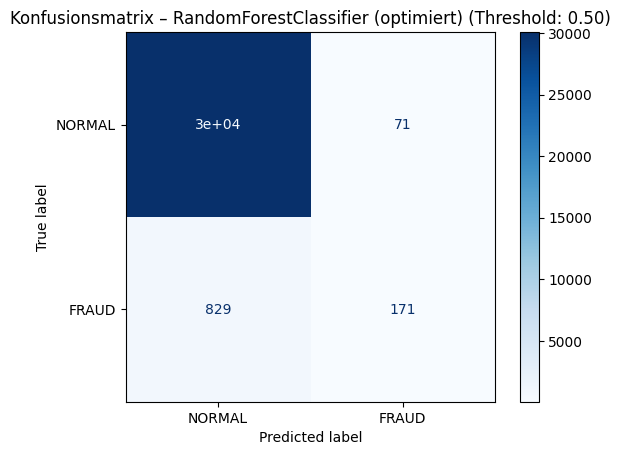

2025-06-03 23:17:16,495 - INFO - 📈 ROC-AUC: 0.8188


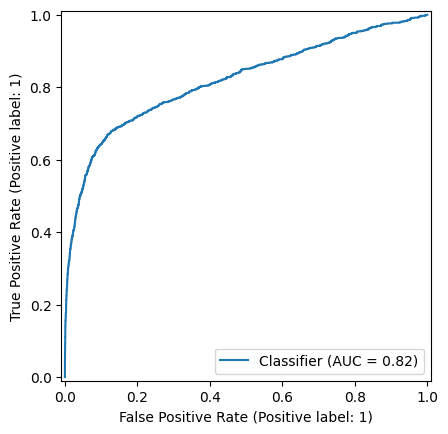

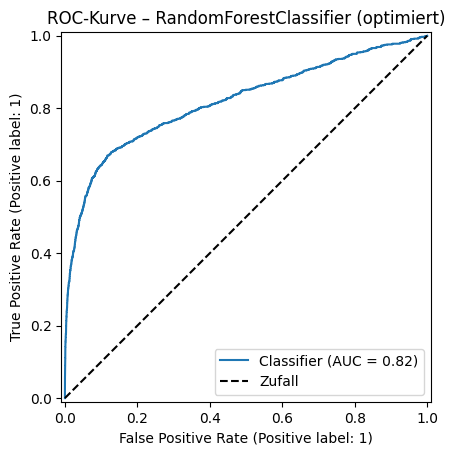

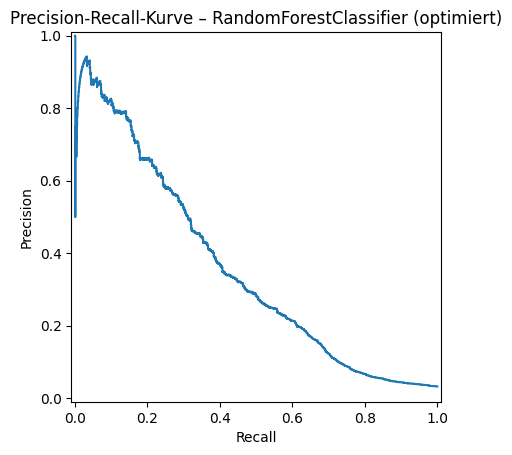

2025-06-03 23:17:16,911 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 300, 'learning_rate': 0.07, 'max_depth': 4, 'subsample': 0.8}



🎯 Wert der Zielfunktion: -6084.04


🔍 Tune: GradientBoostingClassifier


2025-06-03 23:19:40,531 - INFO -   Fold 1 Score: -5459.90
2025-06-03 23:21:37,150 - INFO -   Fold 2 Score: -4995.72
2025-06-03 23:23:34,895 - INFO -   Fold 3 Score: -5088.42
2025-06-03 23:25:33,657 - INFO -   Fold 4 Score: -4879.26
2025-06-03 23:27:30,009 - INFO -   Fold 5 Score: -5222.42
2025-06-03 23:27:30,009 - INFO -   ➡️ Durchschnittlicher CV-Score: -5129.14
2025-06-03 23:27:30,009 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 400, 'learning_rate': 0.07, 'max_depth': 3, 'subsample': 1.0}
2025-06-03 23:29:53,674 - INFO -   Fold 1 Score: -5306.14
2025-06-03 23:32:19,665 - INFO -   Fold 2 Score: -4922.70
2025-06-03 23:34:45,761 - INFO -   Fold 3 Score: -4969.34
2025-06-03 23:37:11,376 - INFO -   Fold 4 Score: -4809.77
2025-06-03 23:39:35,025 - INFO -   Fold 5 Score: -4955.62
2025-06-03 23:39:35,026 - INFO -   ➡️ Durchschnittlicher CV-Score: -4992.71
2025-06-03 23:39:35,027 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth':


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.72      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30067    72]
 [  816   184]]


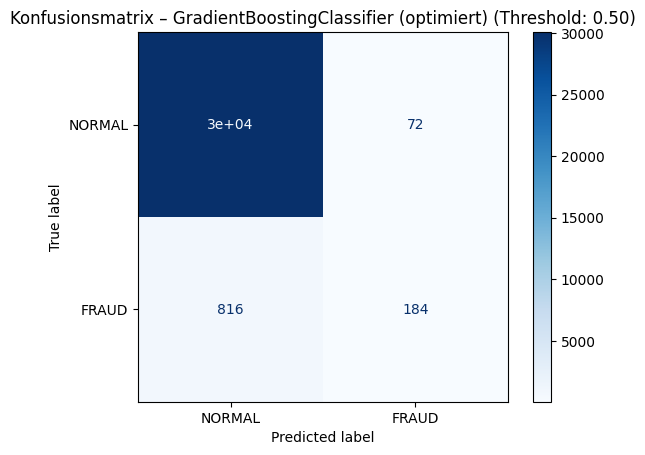

2025-06-05 00:54:50,695 - INFO - 📈 ROC-AUC: 0.8397


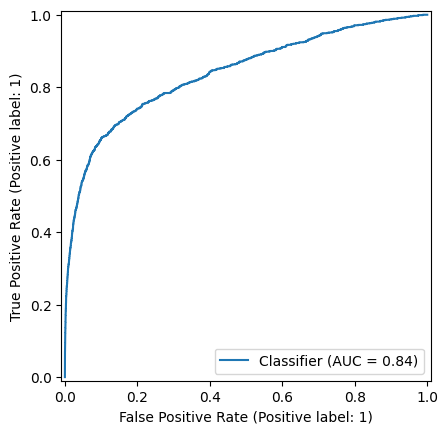

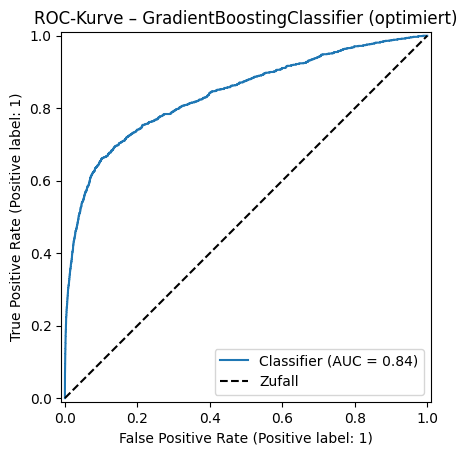

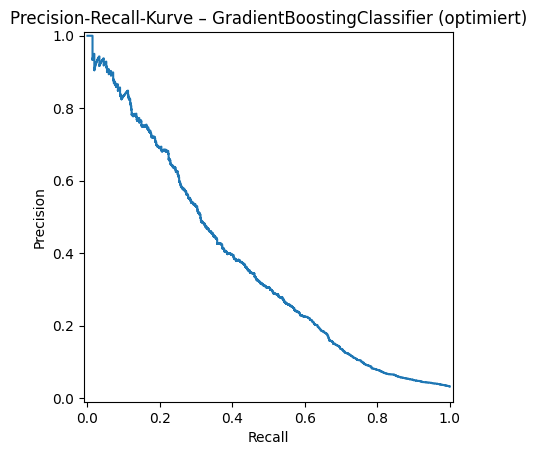

2025-06-05 00:54:51,100 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'learning_rate': 0.07, 'num_leaves': 50, 'max_depth': 5, 'n_jobs': 4}



🎯 Wert der Zielfunktion: -5890.52


🔍 Tune: LGBMClassifier
[LightGBM] [Info] Number of positive: 3200, number of negative: 96442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 99642, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405791
[LightGBM] [Info] Start training from score -3.405791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

2025-06-05 00:54:55,912 - INFO -   Fold 1 Score: -5212.59


[LightGBM] [Info] Number of positive: 3200, number of negative: 96442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2197
[LightGBM] [Info] Number of data points in the train set: 99642, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405791
[LightGBM] [Info] Start training from score -3.405791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-05 00:55:00,774 - INFO -   Fold 2 Score: -4826.34


...

[LightGBM] [Info] Number of positive: 3200, number of negative: 96443
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012549 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 99643, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405801
[LightGBM] [Info] Start training from score -3.405801
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-05 01:17:13,352 - INFO -   Fold 5 Score: -4961.40
2025-06-05 01:17:13,352 - INFO -   ➡️ Durchschnittlicher CV-Score: -4945.97
2025-06-05 01:17:13,353 - INFO - 
✅ Beste Parameter gefunden!
2025-06-05 01:17:13,354 - INFO - ✅ Parameter: {'n_estimators': 300, 'learning_rate': 0.07, 'num_leaves': 60, 'max_depth': 4, 'n_jobs': 4}
2025-06-05 01:17:13,354 - INFO - ✅ CV-Score: -4909.65


[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

2025-06-05 01:17:18,960 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (optimiert)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

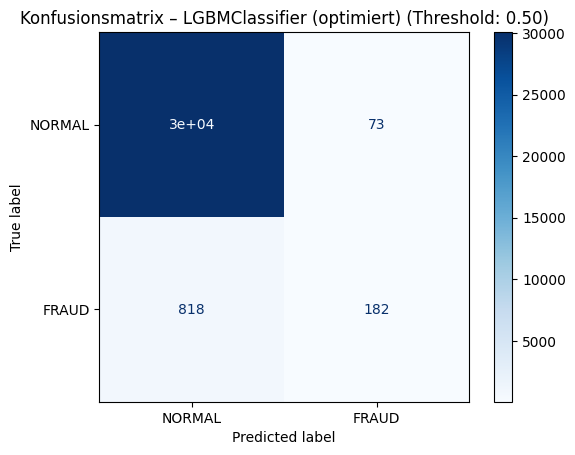

2025-06-05 01:17:26,455 - INFO - 📈 ROC-AUC: 0.8353


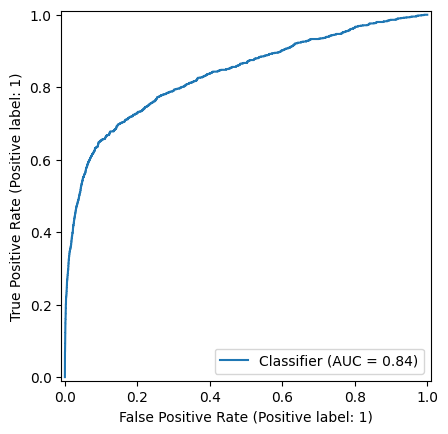

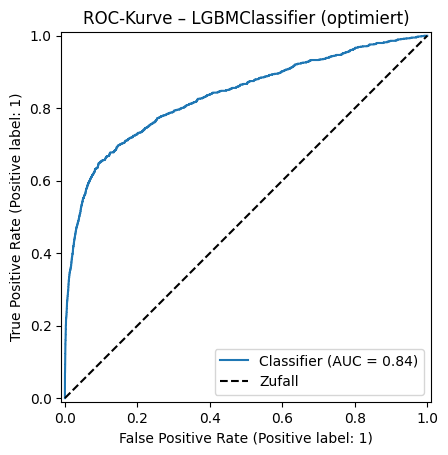

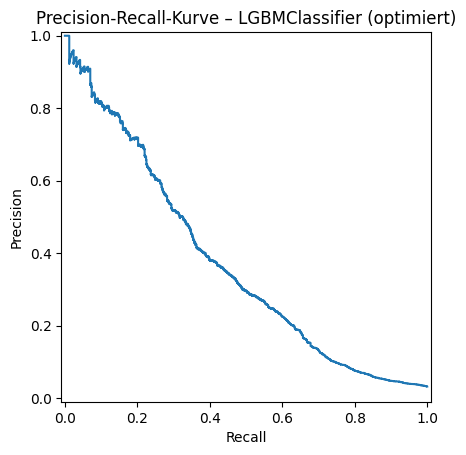

2025-06-05 01:17:26,881 - INFO - 
➡️ Iteration 1: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 6, 'verbose': 0}



🎯 Wert der Zielfunktion: -5942.68


🔍 Tune: CatBoostClassifier


2025-06-05 01:17:34,320 - INFO -   Fold 1 Score: -5095.48
2025-06-05 01:17:41,475 - INFO -   Fold 2 Score: -4775.43
2025-06-05 01:17:48,647 - INFO -   Fold 3 Score: -4805.88
2025-06-05 01:17:55,701 - INFO -   Fold 4 Score: -4643.18
2025-06-05 01:18:02,943 - INFO -   Fold 5 Score: -4917.79
2025-06-05 01:18:02,944 - INFO -   ➡️ Durchschnittlicher CV-Score: -4847.55
2025-06-05 01:18:02,945 - INFO - 
➡️ Iteration 2: teste Parameter {'iterations': 300, 'learning_rate': 0.07, 'depth': 8, 'verbose': 0}
2025-06-05 01:18:14,807 - INFO -   Fold 1 Score: -5136.13
2025-06-05 01:18:26,803 - INFO -   Fold 2 Score: -4835.22
2025-06-05 01:18:38,776 - INFO -   Fold 3 Score: -4969.23
2025-06-05 01:18:50,868 - INFO -   Fold 4 Score: -4797.48
2025-06-05 01:19:02,994 - INFO -   Fold 5 Score: -5012.71
2025-06-05 01:19:02,995 - INFO -   ➡️ Durchschnittlicher CV-Score: -4950.15
2025-06-05 01:19:02,996 - INFO - 
➡️ Iteration 3: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 4, 'verbose': 0}


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30060    79]
 [  811   189]]


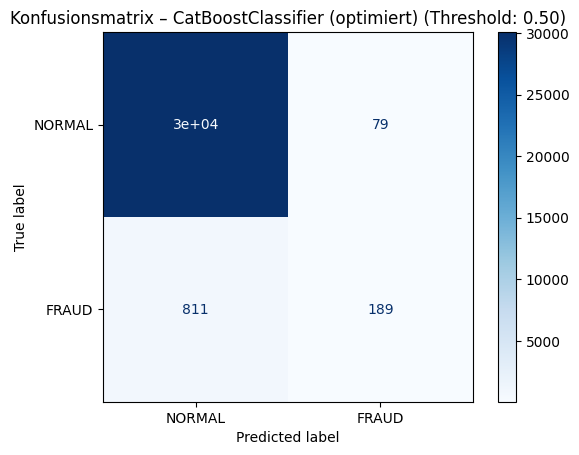

2025-06-05 02:02:08,637 - INFO - 📈 ROC-AUC: 0.8370


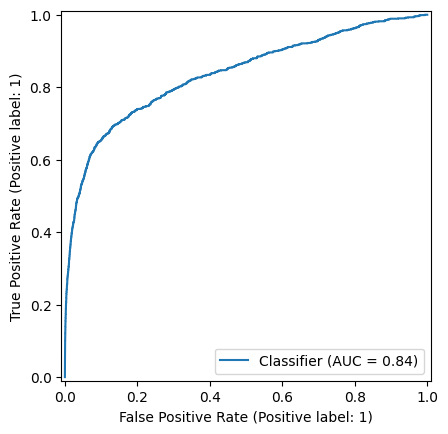

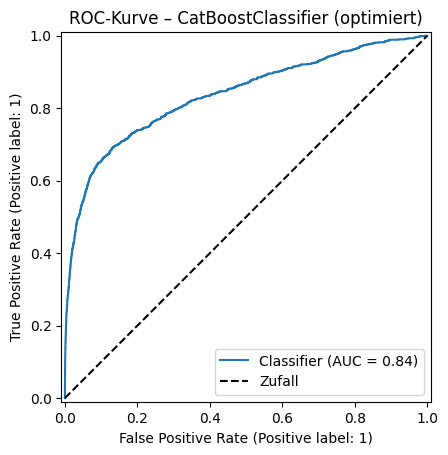

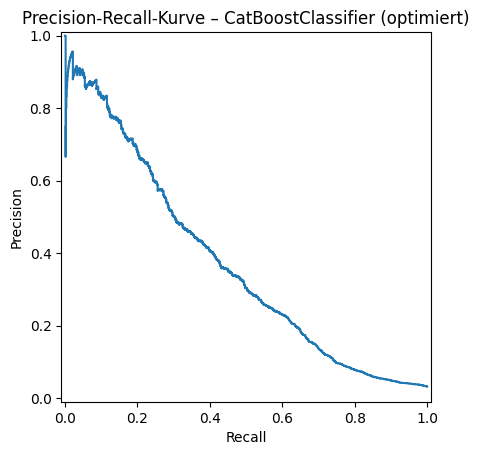


🎯 Wert der Zielfunktion: -5898.38


📊 Zusammenfassung aller Modelle:
                        Model  \
0      RandomForestClassifier   
1  GradientBoostingClassifier   
2              LGBMClassifier   
3          CatBoostClassifier   

                                         Best_Params  CV_Custom_Score  
0  {'n_estimators': 500, 'max_depth': 30, 'min_sa...        -4922.670  
1  {'n_estimators': 400, 'learning_rate': 0.03, '...        -4892.538  
2  {'n_estimators': 300, 'learning_rate': 0.07, '...        -4909.648  
3  {'iterations': 300, 'learning_rate': 0.1, 'dep...        -4829.846  


In [10]:
# Speicher für alle Ergebnisse
results = []

# Master-Loop
for config in model_configs:
    print(f"\n\n==========================")
    print(f"🔍 Tune: {config['name']}")

    best_params, best_score = randomized_search_with_custom_score(
        model_class=config['model_class'],
        param_grid=config['param_grid'],
        preprocessor=preprocessor,
        X=X_train,
        y=y_train,
        damage_series=damage_train,
        n_iter=50,                          # jetzt mit 50 statt 10 Iterationen
        cv_splits=5,
        model_fixed_params=config['fixed_params']
    )
    
    # Merge fixed + best params
    full_params = {**best_params, **config['fixed_params']}

    # Train final model
    try:
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params, random_state=42))
        ])
    except TypeError:
        # Falls random_state nicht unterstützt wird
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params))
        ])

    final_pipeline.fit(X_train, y_train)

    # Evaluate on testset
    evaluate_model_with_curves(
        model=final_pipeline.named_steps['classifier'],
        model_name=config['name'] + " (optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=0.5
    )

    # Ergebnis speichern
    results.append({
        'Model': config['name'],
        'Best_Params': full_params,
        'CV_Custom_Score': best_score
    })

# Zusammenfassung als DataFrame:
results_df = pd.DataFrame(results)
print("\n\n📊 Zusammenfassung aller Modelle:")
print(results_df)


## 7. Threshold-Optimierer

In [11]:
def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    """
    Findet den besten Threshold, der den Custom Objective Score maximiert.
    """
    # Pipeline für Preprocessing
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit auf Gesamtdaten (hier wird idR vorher schon fit sein - zur Sicherheit)
    pipeline.fit(X_train, y_train)

    # Prüfen, ob Modell Wahrscheinlichkeiten liefert
    if not hasattr(model, "predict_proba"):
        print("⚠️ Dieses Modell unterstützt kein predict_proba. Threshold-Optimierung nicht möglich.")
        return None, None

    y_scores = pipeline.predict_proba(X_test)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"🎯 Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score


## 8. Threshold-Optimierer für alle Modelle

In [12]:
# Wir bauen zuerst eine Zuordnung: Modellname → Modellklasse
model_name_to_class = {
    'RandomForestClassifier': RandomForestClassifier,
    'GradientBoostingClassifier': GradientBoostingClassifier,
    'LGBMClassifier': LGBMClassifier,
    'CatBoostClassifier': CatBoostClassifier
}

# Hier speichern wir die Ergebnisse
threshold_results = []

# Loop über alle Modelle in results_df
for idx, row in results_df.iterrows():
    model_name = row['Model']
    best_params = row['Best_Params']
    model_class = model_name_to_class[model_name]

    print(f"\n🚀 Threshold-Optimierung für: {model_name}")
    
    # Modell initialisieren mit den besten Parametern
    try:
        model = model_class(**best_params)
    except TypeError:
        # Falls random_state nicht unterstützt wird
        best_params_copy = best_params.copy()
        best_params_copy.pop('random_state', None)
        model = model_class(**best_params_copy)

    # Pipeline definieren
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Modell final auf dem gesamten Trainingsset trainieren
    pipeline.fit(X_train, y_train)

    # Threshold-Optimierung durchführen
    best_threshold, best_score = find_best_threshold(
        model=model, 
        preprocessor=preprocessor, 
        X_test=X_test, 
        y_test=y_test, 
        damage_test=damage_test
    )

    threshold_results.append({
        'Model': model_name,
        'Best_Threshold': best_threshold,
        'Test_Custom_Score': best_score
    })

# In DataFrame umwandeln
threshold_df = pd.DataFrame(threshold_results)

# Merge mit deinem bisherigen results_df:
final_results_df = pd.merge(results_df, threshold_df, on='Model')

# Ausgabe
print("\n📊 Finales Ergebnis mit Threshold-Optimierung:")
print(final_results_df)



🚀 Threshold-Optimierung für: RandomForestClassifier
🎯 Optimaler Threshold: 0.40 mit Custom Score: -5928.93

🚀 Threshold-Optimierung für: GradientBoostingClassifier
🎯 Optimaler Threshold: 0.39 mit Custom Score: -5623.87

🚀 Threshold-Optimierung für: LGBMClassifier
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

## -----

## LGBMClassifier

In [13]:
model_configs2 = [
    {
        'name': 'LGBMClassifier',
        'model_class': LGBMClassifier,
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.03, 0.05, 0.07],
            'num_leaves': [40, 50, 60],
            'max_depth': [4, 5, 6]         
        },
        'fixed_params': {'n_jobs': 4}
    },
    
] 

2025-06-05 07:16:11,324 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'learning_rate': 0.07, 'num_leaves': 50, 'max_depth': 5, 'n_jobs': 4}




🔍 Tune: LGBMClassifier
[LightGBM] [Info] Number of positive: 3200, number of negative: 96442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 99642, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405791
[LightGBM] [Info] Start training from score -3.405791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

2025-06-05 07:16:16,672 - INFO -   Fold 1 Score: -5212.59


[LightGBM] [Info] Number of positive: 3200, number of negative: 96442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2197
[LightGBM] [Info] Number of data points in the train set: 99642, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405791
[LightGBM] [Info] Start training from score -3.405791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-05 07:16:21,811 - INFO -   Fold 2 Score: -4826.34


...

[LightGBM] [Info] Number of positive: 3200, number of negative: 96443
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 99643, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405801
[LightGBM] [Info] Start training from score -3.405801
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-05 07:37:21,507 - INFO -   Fold 5 Score: -4985.03
2025-06-05 07:37:21,507 - INFO -   ➡️ Durchschnittlicher CV-Score: -4917.58
2025-06-05 07:37:21,507 - INFO - 
✅ Beste Parameter gefunden!
2025-06-05 07:37:21,507 - INFO - ✅ Parameter: {'n_estimators': 300, 'learning_rate': 0.07, 'num_leaves': 60, 'max_depth': 4, 'n_jobs': 4}
2025-06-05 07:37:21,507 - INFO - ✅ CV-Score: -4909.65


[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

2025-06-05 07:37:27,484 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (optimiert)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

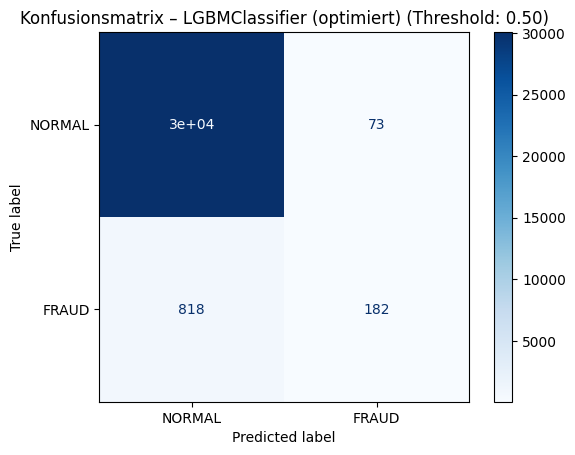

2025-06-05 07:37:34,783 - INFO - 📈 ROC-AUC: 0.8353


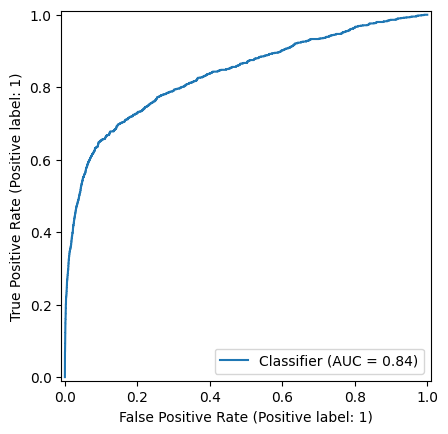

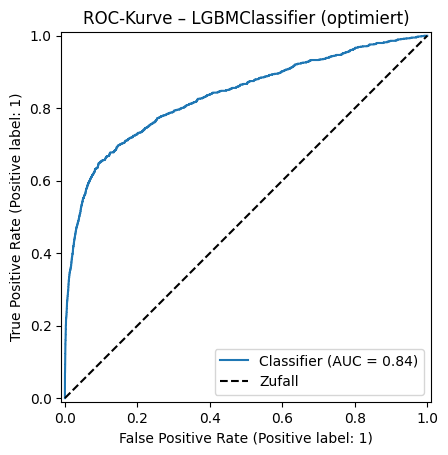

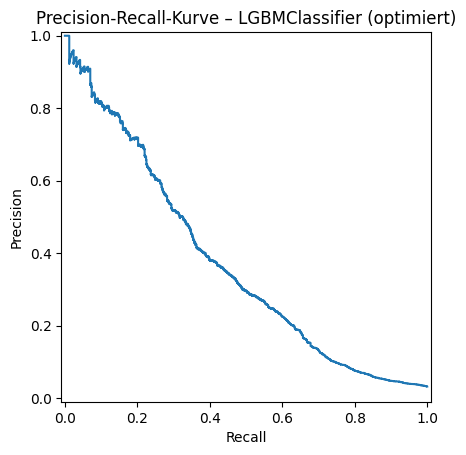


🎯 Wert der Zielfunktion: -5942.68


📊 Zusammenfassung aller Modelle:
            Model                                        Best_Params  \
0  LGBMClassifier  {'n_estimators': 300, 'learning_rate': 0.07, '...   

   CV_Custom_Score  
0        -4909.648  


In [14]:
# Speicher für alle Ergebnisse
results = []

# Master-Loop
for config in model_configs2:
    print(f"\n\n==========================")
    print(f"🔍 Tune: {config['name']}")

    best_params, best_score = randomized_search_with_custom_score(
        model_class=config['model_class'],
        param_grid=config['param_grid'],
        preprocessor=preprocessor,
        X=X_train,
        y=y_train,
        damage_series=damage_train,
        n_iter=45,                          # jetzt mit 45 statt 10 Iterationen
        cv_splits=5,
        model_fixed_params=config['fixed_params']
    )
    
    # Merge fixed + best params
    full_params = {**best_params, **config['fixed_params']}

    # Train final model
    try:
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params, random_state=42))
        ])
    except TypeError:
        # Falls random_state nicht unterstützt wird
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params))
        ])

    final_pipeline.fit(X_train, y_train)

    # Evaluate on testset
    evaluate_model_with_curves(
        model=final_pipeline.named_steps['classifier'],
        model_name=config['name'] + " (optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=0.5
    )

    # Ergebnis speichern
    results.append({
        'Model': config['name'],
        'Best_Params': full_params,
        'CV_Custom_Score': best_score
    })

# Zusammenfassung als DataFrame:
results_df = pd.DataFrame(results)
print("\n\n📊 Zusammenfassung aller Modelle:")
print(results_df)


In [15]:
def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    """
    Findet den besten Threshold, der den Custom Objective Score maximiert.
    """
    # Pipeline für Preprocessing
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit auf Gesamtdaten (hier wird idR vorher schon fit sein - zur Sicherheit)
    pipeline.fit(X_train, y_train)

    # Prüfen, ob Modell Wahrscheinlichkeiten liefert
    if not hasattr(model, "predict_proba"):
        print("⚠️ Dieses Modell unterstützt kein predict_proba. Threshold-Optimierung nicht möglich.")
        return None, None

    y_scores = pipeline.predict_proba(X_test)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"🎯 Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score


In [16]:
# Wir bauen zuerst eine Zuordnung: Modellname → Modellklasse
model_name_to_class = {
    'RandomForestClassifier': RandomForestClassifier,
    'GradientBoostingClassifier': GradientBoostingClassifier,
    'LGBMClassifier': LGBMClassifier,
    'CatBoostClassifier': CatBoostClassifier
}

# Hier speichern wir die Ergebnisse
threshold_results = []

# Loop über alle Modelle in results_df
for idx, row in results_df.iterrows():
    model_name = row['Model']
    best_params = row['Best_Params']
    model_class = model_name_to_class[model_name]

    print(f"\n🚀 Threshold-Optimierung für: {model_name}")
    
    # Modell initialisieren mit den besten Parametern
    try:
        model = model_class(**best_params)
    except TypeError:
        # Falls random_state nicht unterstützt wird
        best_params_copy = best_params.copy()
        best_params_copy.pop('random_state', None)
        model = model_class(**best_params_copy)

    # Pipeline definieren
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Modell final auf dem gesamten Trainingsset trainieren
    pipeline.fit(X_train, y_train)

    # Threshold-Optimierung durchführen
    best_threshold, best_score = find_best_threshold(
        model=model, 
        preprocessor=preprocessor, 
        X_test=X_test, 
        y_test=y_test, 
        damage_test=damage_test
    )

    threshold_results.append({
        'Model': model_name,
        'Best_Threshold': best_threshold,
        'Test_Custom_Score': best_score
    })

# In DataFrame umwandeln
threshold_df = pd.DataFrame(threshold_results)

# Merge mit deinem bisherigen results_df:
final_results_df = pd.merge(results_df, threshold_df, on='Model')

# Ausgabe
print("\n📊 Finales Ergebnis mit Threshold-Optimierung:")
print(final_results_df)



🚀 Threshold-Optimierung für: LGBMClassifier
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

## -----------

In [17]:
model_configs3 = [
    {
        'name': 'CatBoostClassifier',
        'model_class': CatBoostClassifier,
        'param_grid': {
            'iterations': [100, 300, 500],
            'learning_rate': [0.05, 0.07, 0.1],
            'depth': [4, 6, 8]
        },
        'fixed_params': {'verbose': 0}
    }
] 

2025-06-05 07:42:15,143 - INFO - 
➡️ Iteration 1: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 6, 'verbose': 0}




🔍 Tune: CatBoostClassifier


2025-06-05 07:42:22,050 - INFO -   Fold 1 Score: -5095.48
2025-06-05 07:42:29,088 - INFO -   Fold 2 Score: -4775.43
2025-06-05 07:42:35,954 - INFO -   Fold 3 Score: -4805.88
2025-06-05 07:42:42,983 - INFO -   Fold 4 Score: -4643.18
2025-06-05 07:42:50,230 - INFO -   Fold 5 Score: -4917.79
2025-06-05 07:42:50,230 - INFO -   ➡️ Durchschnittlicher CV-Score: -4847.55
2025-06-05 07:42:50,230 - INFO - 
➡️ Iteration 2: teste Parameter {'iterations': 300, 'learning_rate': 0.07, 'depth': 8, 'verbose': 0}
2025-06-05 07:43:02,732 - INFO -   Fold 1 Score: -5136.13
2025-06-05 07:43:14,899 - INFO -   Fold 2 Score: -4835.22
2025-06-05 07:43:27,345 - INFO -   Fold 3 Score: -4969.23
2025-06-05 07:43:39,983 - INFO -   Fold 4 Score: -4797.48
2025-06-05 07:43:52,386 - INFO -   Fold 5 Score: -5012.71
2025-06-05 07:43:52,386 - INFO -   ➡️ Durchschnittlicher CV-Score: -4950.15
2025-06-05 07:43:52,386 - INFO - 
➡️ Iteration 3: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 4, 'verbose': 0}


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30060    79]
 [  811   189]]


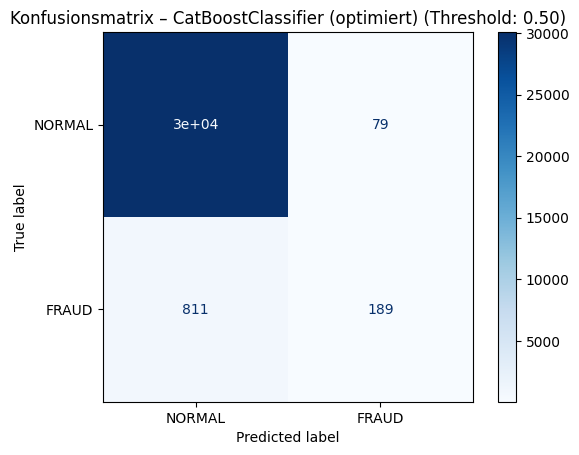

2025-06-05 08:27:08,322 - INFO - 📈 ROC-AUC: 0.8370


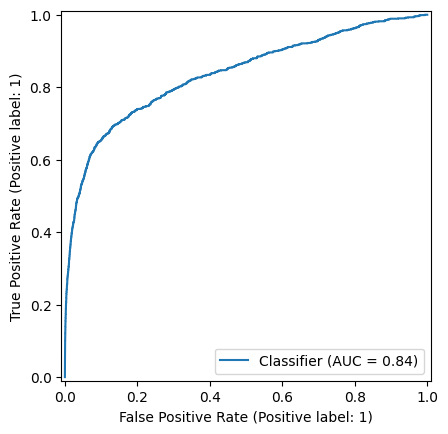

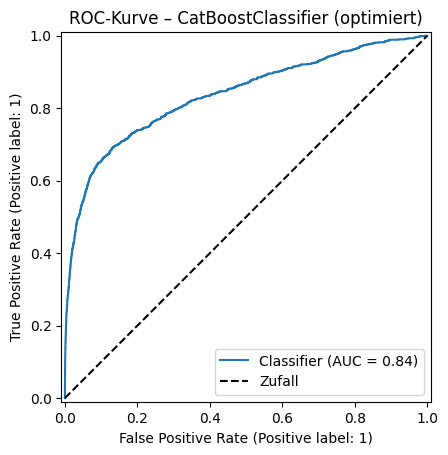

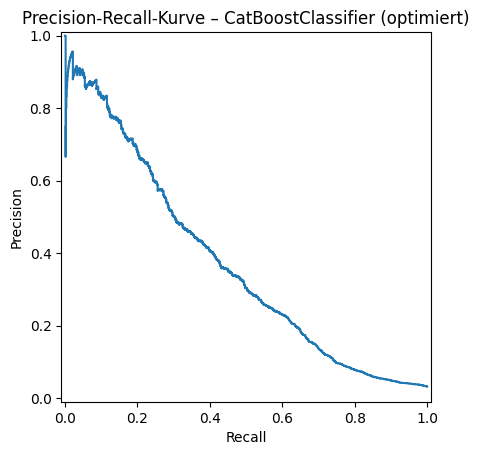


🎯 Wert der Zielfunktion: -5898.38


📊 Zusammenfassung aller Modelle:
                Model                                        Best_Params  \
0  CatBoostClassifier  {'iterations': 300, 'learning_rate': 0.1, 'dep...   

   CV_Custom_Score  
0        -4829.846  


In [19]:
# Speicher für alle Ergebnisse
results = []

# Master-Loop
for config in model_configs3:
    print(f"\n\n==========================")
    print(f"🔍 Tune: {config['name']}")

    best_params, best_score = randomized_search_with_custom_score(
        model_class=config['model_class'],
        param_grid=config['param_grid'],
        preprocessor=preprocessor,
        X=X_train,
        y=y_train,
        damage_series=damage_train,
        n_iter=50,                          # jetzt mit 50 statt 10 Iterationen
        cv_splits=5,
        model_fixed_params=config['fixed_params']
    )
    
    # Merge fixed + best params
    full_params = {**best_params, **config['fixed_params']}

    # Train final model
    try:
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params, random_state=42))
        ])
    except TypeError:
        # Falls random_state nicht unterstützt wird
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params))
        ])

    final_pipeline.fit(X_train, y_train)

    # Evaluate on testset
    evaluate_model_with_curves(
        model=final_pipeline.named_steps['classifier'],
        model_name=config['name'] + " (optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=0.5
    )

    # Ergebnis speichern
    results.append({
        'Model': config['name'],
        'Best_Params': full_params,
        'CV_Custom_Score': best_score
    })

# Zusammenfassung als DataFrame:
results_df = pd.DataFrame(results)
print("\n\n📊 Zusammenfassung aller Modelle:")
print(results_df)


In [20]:
def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    """
    Findet den besten Threshold, der den Custom Objective Score maximiert.
    """
    # Pipeline für Preprocessing
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit auf Gesamtdaten (hier wird idR vorher schon fit sein - zur Sicherheit)
    pipeline.fit(X_train, y_train)

    # Prüfen, ob Modell Wahrscheinlichkeiten liefert
    if not hasattr(model, "predict_proba"):
        print("⚠️ Dieses Modell unterstützt kein predict_proba. Threshold-Optimierung nicht möglich.")
        return None, None

    y_scores = pipeline.predict_proba(X_test)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"🎯 Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score


In [21]:
# Wir bauen zuerst eine Zuordnung: Modellname → Modellklasse
model_name_to_class = {
    'RandomForestClassifier': RandomForestClassifier,
    'GradientBoostingClassifier': GradientBoostingClassifier,
    'LGBMClassifier': LGBMClassifier,
    'CatBoostClassifier': CatBoostClassifier
}

# Hier speichern wir die Ergebnisse
threshold_results = []

# Loop über alle Modelle in results_df
for idx, row in results_df.iterrows():
    model_name = row['Model']
    best_params = row['Best_Params']
    model_class = model_name_to_class[model_name]

    print(f"\n🚀 Threshold-Optimierung für: {model_name}")
    
    # Modell initialisieren mit den besten Parametern
    try:
        model = model_class(**best_params)
    except TypeError:
        # Falls random_state nicht unterstützt wird
        best_params_copy = best_params.copy()
        best_params_copy.pop('random_state', None)
        model = model_class(**best_params_copy)

    # Pipeline definieren
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Modell final auf dem gesamten Trainingsset trainieren
    pipeline.fit(X_train, y_train)

    # Threshold-Optimierung durchführen
    best_threshold, best_score = find_best_threshold(
        model=model, 
        preprocessor=preprocessor, 
        X_test=X_test, 
        y_test=y_test, 
        damage_test=damage_test
    )

    threshold_results.append({
        'Model': model_name,
        'Best_Threshold': best_threshold,
        'Test_Custom_Score': best_score
    })

# In DataFrame umwandeln
threshold_df = pd.DataFrame(threshold_results)

# Merge mit deinem bisherigen results_df:
final_results_df = pd.merge(results_df, threshold_df, on='Model')

# Ausgabe
print("\n📊 Finales Ergebnis mit Threshold-Optimierung:")
print(final_results_df)



🚀 Threshold-Optimierung für: CatBoostClassifier
🎯 Optimaler Threshold: 0.45 mit Custom Score: -5771.91

📊 Finales Ergebnis mit Threshold-Optimierung:
                Model                                        Best_Params  \
0  CatBoostClassifier  {'iterations': 300, 'learning_rate': 0.1, 'dep...   

   CV_Custom_Score  Best_Threshold  Test_Custom_Score  
0        -4829.846            0.45           -5771.91  


------------------------------------------------------------
# Zusammenfassung:
## Hyperparameter-Optimierung
Im Rahmen des Modelltrainings wurden vier unterschiedliche Klassifikatoren einer systematischen Hyperparameter-Optimierung unterzogen: RandomForestClassifier, GradientBoostingClassifier (sklearn), LGBMClassifier (LightGBM), CatBoostClassifier

**Vorgehen:** Die Hyperparameter wurden mittels einer Randomized Search / Custom Grid Search optimiert. Bewertet wurden die Modelle mit einer eigens definierten Custom Loss Function (geschäftslogisch gewichtet). 
Zur Bewertung der Modellgüte diente ein 5-faches Cross-Validation-Verfahren.

**Optimierte Parameter:**
- RandomForestClassifier: Beste Hyperparameter: n_estimators=500, max_depth=30, min_samples_split=5, min_samples_leaf=1, class_weight='balanced'; Bester CV-Score: -4922.67
- GradientBoostingClassifier: Beste Hyperparameter: n_estimators=400, learning_rate=0.03, max_depth=5, min_samples_split=5, min_samples_leaf=2; Bester CV-Score: -4892.54
- LGBMClassifier: Beste Hyperparameter: n_estimators=300, learning_rate=0.07, num_leaves=60, max_depth=4; Bester CV-Score: -4909.65
- CatBoostClassifier: Beste Hyperparameter: iterations=300, learning_rate=0.1, depth=6; Bester CV-Score: -4829.85

**Erkenntnisse:** CatBoostClassifier erzielte den besten CV-Score auf den Trainingsdaten. GradientBoostingClassifier zeigte auf den Testdaten eine bessere Generalisierungsfähigkeit.

## Threshold-Optimierung
Aufgrund des starken Klassenungleichgewichts war der Standard-Schwellenwert von 0.5 für die Klassifikationsentscheidung nicht optimal. Ziel war es, durch Threshold-Optimierung das Verhältnis von Precision und Recall an den Business-Kontext anzupassen und die Custom Loss weiter zu minimieren.

**Vorgehen:** Für jedes optimierte Modell wurde der Klassifikationsschwellenwert systematisch im Bereich [0.1, 0.9] variiert. Zielgröße war die Minimierung der Custom Loss auf dem Validierungs- bzw. Testset.

**Optimale Thresholds und Test-Performance:**
Modell	Optimaler Threshold	Test Custom Loss
- RandomForestClassifier: Optimaler Threshold: 0.40; Test Custom Loss: -5928.93
- GradientBoostingClassifier: Optimaler Threshold: 0.39; Test Custom Loss: -5623.87
- LGBMClassifier: Optimaler Threshold: 0.43; Test Custom Loss: -5643.49
- CatBoostClassifier: Optimaler Threshold: 0.45; Test Custom Loss: -5771.91

**Erkenntnisse:** Alle Modelle profitieren signifikant von einer Absenkung des Thresholds unter 0.5. Der GradientBoostingClassifier erzielte nach Threshold-Optimierung den besten Wert auf den Testdaten. Die Threshold-Optimierung trug wesentlich zur Steigerung der Business-relevanten Modellgüte bei.